### 1 a) Simulación del proceso de Envejecimiento Saludable
El modelo Windkessel de 2 elementos ($WK_2$) representa la circulación sistémica mediante dos parámetros:
* **Compliance Arterial ($C_A$)**: Representa la elasticidad de las arterias principales.
* **Resistencia Periférica ($R_P$)**: Representa la oposición al flujo sanguíneo en los vasos más pequeños (arteriolas).

**Fisiología del envejecimiento:** Con el paso de los años, las paredes arteriales se vuelven más rígidas (menor distensibilidad), lo que se traduce en una **disminución de la compliance ($C_A$)**. Como mecanismo de compensación y debido a cambios vasculares, suele existir un **aumento en la resistencia periférica ($R_P$)**.

A continuación, reduciremos $C_A$ y aumentaremos $R_P$ respecto a los valores basales del paciente sano para observar cómo se amplía la presión de pulso (diferencia entre la presión sistólica y diastólica).

In [ ]:
# -------------------------------------------------------------------------
# MÓDULOS DE USO GENERAL Y FUNCIÓN DE FLUJO
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

def Q_Sim(Qmax, T, t):
    """
    ===============================================================================
    Flujo_Sim: Generación de una señal de FLUJO (Semiseno) similar al humano [ml/s]
    Parámetros de entrada:
      -Qmax: Flujo Máximo
      -T: Duración de un período
      -t: Rango de evaluación
    ==============================================================================
    """
    Escala_ml = 1e5 * (Qmax / 8.8) #Ajuste a (500 ml/s)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [ ]:
# -------------------------------------------------------------------------
# RESOLUCIÓN NUMÉRICA DEL MODELO WK2
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    """
    Resuelve el modelo Windkessel de 2 elementos (WK2) usando el método de Euler.
    """
    dt = t[1] - t[0]              # Paso de integración (período de muestreo)
    P = np.zeros(len(t))          # Vector inicializado en ceros para la Presión

    # Condición inicial: asumiendo una presión diastólica de arranque (ej: 80 mmHg)
    P[0] = 80.0

    # Bucle de Euler para resolver paso a paso
    for i in range(1, len(t)):
        # Derivada de la Presión: dP/dt = Q/Ca - P/(Rp*Ca)
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        # Actualización
        P[i] = P[i-1] + (dP_dt * dt)

    return P

### Resolución Numérica y Visualización (Procesamiento de Señales)
Teniendo nuestro vector de flujo $Q(t)$ actuando como la excitación del sistema y nuestra frecuencia de muestreo establecida, ahora resolvemos la **Ecuación Diferencial Ordinaria (EDO)** del $WK_2$:

$\frac{dP_{AO}}{dt} = \frac{Q(t)}{C_A} - \frac{P_{AO}(t)}{R_P \cdot C_A}$

Como en DSP trabajamos con señales discretas, podemos integrar esta ecuación paso a paso utilizando el método de Euler. Luego, graficamos el resultado para analizar la morfología de la nueva onda de presión aórtica.

Parámetros Basales -> Ca: 1.10 | Rp: 0.90
Parámetros Envejecimiento -> Ca: 0.66 | Rp: 1.17


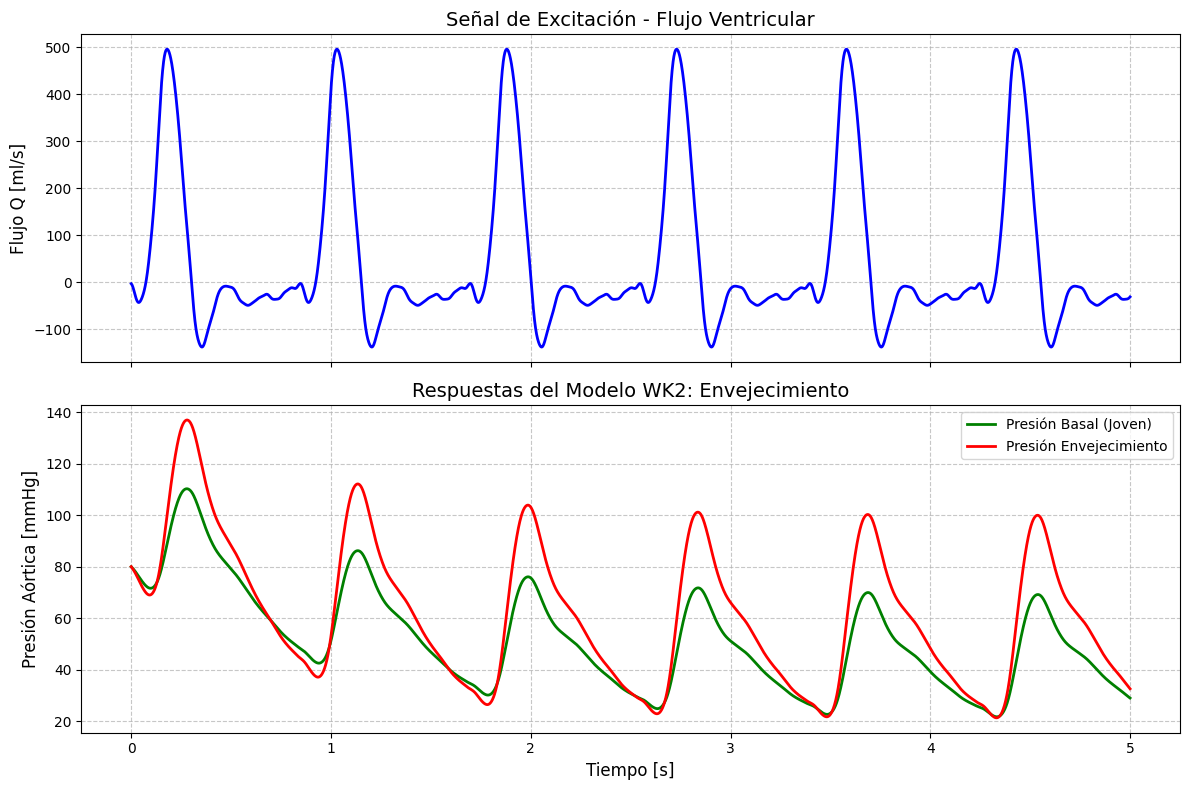

In [ ]:
# -------------------------------------------------------------------------
# SIMULACIÓN 1a: ENVEJECIMIENTO SALUDABLE Y VISUALIZACIÓN
# -------------------------------------------------------------------------

# 1. Parámetros temporales y de flujo
Ts = 0.001                  # Período de muestreo (segundos)
t = np.arange(0, 5, Ts)     # Rango de evaluación (5 segundos para apreciar bien los latidos)
T0 = 0.85                   # Duración de un latido
Qmax = 500                  # Flujo Máximo [ml/s]

# Generación del vector de excitación (Flujo)
Q_entrada = Q_Sim(Qmax, T0, t)

# 2. Parámetros Fisiológicos Basales (Valores típicos de referencia)
Ca_basal = 1.1  # ml/mmHg
Rp_basal = 0.9  # mmHg·s/ml

# 3. Alteración fisiológica por Envejecimiento Saludable:
# - Cae la distensibilidad de las arterias (menor Ca)
# - Sube la resistencia periférica (mayor Rp)
Ca_env = Ca_basal * 0.60
Rp_env = Rp_basal * 1.30

print(f"Parámetros Basales -> Ca: {Ca_basal:.2f} | Rp: {Rp_basal:.2f}")
print(f"Parámetros Envejecimiento -> Ca: {Ca_env:.2f} | Rp: {Rp_env:.2f}")

# 4. Resolución del modelo para ambos casos (para comparar visualmente)
P_basal = resolver_wk2_euler(Q_entrada, t, Ca_basal, Rp_basal)
P_env = resolver_wk2_euler(Q_entrada, t, Ca_env, Rp_env)

# 5. Ploteo de los resultados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico Superior: Señal de Excitación (Flujo)
ax1.plot(t, Q_entrada, 'b', linewidth=2)
ax1.set_ylabel('Flujo Q [ml/s]', fontsize=12)
ax1.set_title('Señal de Excitación - Flujo Ventricular', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico Inferior: Señales de Respuesta (Presiones)
ax2.plot(t, P_basal, 'g', linewidth=2, label='Presión Basal (Joven)')
ax2.plot(t, P_env, 'r', linewidth=2, label='Presión Envejecimiento')
ax2.set_xlabel('Tiempo [s]', fontsize=12)
ax2.set_ylabel('Presión Aórtica [mmHg]', fontsize=12)
ax2.set_title('Respuestas del Modelo WK2: Envejecimiento', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Conclusión del análisis (1 a)

A partir de los resultados simulados para el envejecimiento saludable, podemos observar que la pérdida de distensibilidad arterial (reducción de la compliance $C_A$) genera un ensanchamiento significativo de la presión de pulso. Al volverse más rígidas, las arterias pierden su capacidad para amortiguar el pico de la onda de flujo eyectada por el ventrículo izquierdo (actúan como un capacitor de menor valor, filtrando menos la señal), lo que provoca una presión sistólica más elevada. Por otro lado, el aumento compensatorio de la resistencia periférica ($R_P$) intenta mantener la presión media, pero la morfología general de la onda de presión aórtica presenta una mayor amplitud o rizado (ripple) respecto a la de un paciente joven y sano.
